# Music Source Separation - Deep Learning Final Project
---
**Music Source Separation** (MSS) is isolating a track from a composed music source (songs in our case).

In this project we implement and compare several architectures to do vocal separation - a sub task of MSS. 




**This notebook presents our vocal separation project. In it you will find:**
1. Imports and Enviorment setup
2. Dataset showcase
3. Models
4. Curricular Training
5. Inference example
6. User song inference
7. Failed and Successful Experiments


## Environment Setup and Imports

Note for reviewer:
-  Please make sure you install and activate the environment via the .yml file
- Run the project on cuda for fast inference


In [ ]:
import sys  
import os
import numpy as np
import importlib
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import src.utils as utils
import src.config as config

from torch.utils.data import DataLoader
from src import models as ma
from pathlib import Path
from IPython.display import Audio, display

importlib.reload(utils)
importlib.reload(config)
importlib.reload(ma)
setup_config = utils.setup_project_environment()

config.GENERAL_CONFIG.update(setup_config)
config.SHARED_CONFIG.update(setup_config)

utils.set_seed(config.GENERAL_CONFIG['seed'])

## The data base: MUSDB18

The database we found contains 10~ of songs. Each song has 5 tracks: Mixture, vocals, drums, bass and other.


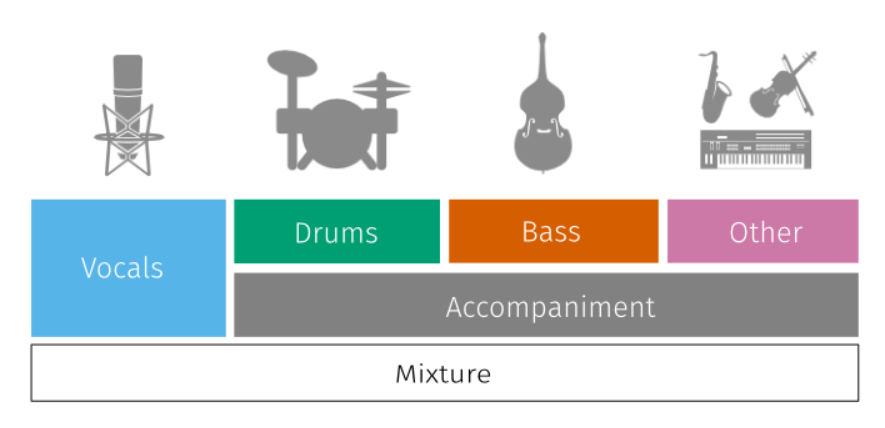

## Data Preprocessing

We split each song into 8 second chunks so it fits the models. After that we applied STFT on the chunks.


## Models

**Model 1 (LSTM):** Sequential bidirectional LSTM with masking output.

**Model 2 (U-Net):** 2D CNN encoder-decoder with skip connections.

## Train Both Models - Stage 1

Sequential training: LSTM first, then U-Net

In [ ]:
model_names = ["lstm","unet"]
lstm_hp, unet_hp = config.LSTM_HYPERPARAMETERS, config.UNET_HYPERPARAMETERS
shared_config = config.SHARED_CONFIG
general_config = config.GENERAL_CONFIG
stage_list= [1, 1]
stage = 1
models = utils.train_models(
    model_names=model_names,
    stage_list= [1, 1],
    hp_list= [lstm_hp, unet_hp],
    shared_config=shared_config
)


## Stage 1 Test Evaluation

Compute loss on held-out test set (forward pass only) to assess generalization.


In [ ]:
lstm = models['lstm']
unet = models['unet']


tests = utils.test_models(
    model_list=[lstm,unet],
    stage_list=stage_list,    
    config=shared_config
)

utils.plot_learning_comparison(
    [lstm,unet],
    [tests['lstm'], tests['unet']], 
    "Training Comparison - Stage 1"
)

## Stage 1 Evaluation (Spectrograms + Audio)

Compare LSTM vs U-Net separation quality on Stage 1 test samples.

In [ ]:
print("="*70)
print("STAGE 1 EVALUATION: Simplified Mixture (Vocals+Other) → Other")
print("="*70)

device = shared_config['device']

audio_data = utils.load_and_stitch_test_chunks(general_config=general_config,stage=stage)
predictions = utils.eval_models([lstm,unet],audio_data, shared_config)


# 3. VISUALIZE PRE-COMPUTED RESULTS
# Using your new function to handle the plots and audio players
utils.visualize_results(
    predictions=predictions,
    model_list=[lstm,unet],
    audio_data=audio_data,
    stage=stage,
    general_config=general_config
)

## Train Both Models - Stage 2

Curriculum step: Stage 2 uses 4→1 channels and continues from Stage 1 weights.

In [ ]:
stage_list = [2,2]
stage = 2
models = utils.train_models(
    model_names=model_names,
    stage_list=[2,2],
    hp_list= [lstm_hp, unet_hp],
    shared_config=shared_config
)


## Stage 2 Test Evaluation

Compute loss on held-out test set (forward pass only) to assess generalization.


In [ ]:
lstm = models['lstm']
unet = models['unet']


tests = utils.test_models(
    model_list=[lstm,unet],
    stage_list=stage_list,    
    config=shared_config
)

utils.plot_learning_comparison(
    [lstm,unet],
    [tests['lstm'], tests['unet']], 
    "Training Comparison - Stage 2 (Full Mix -> Accompaniment)"
)


## Stage 2 Evaluation (Spectrograms + Audio)

Compare LSTM vs U-Net separation quality on Stage 2 test samples.

In [ ]:
device = shared_config['device']

audio_data = utils.load_and_stitch_test_chunks(general_config=general_config,stage=stage)
predictions = utils.eval_models([lstm,unet],audio_data, shared_config)


utils.visualize_results(
    predictions=predictions,
    model_list=[lstm,unet],
    audio_data=audio_data,
    stage=stage,
    general_config=general_config
)

## Quantitative Evaluation

Compute BSS metrics (SDR/SIR/SAR) on test set using museval library.

In [ ]:
checkpoint_dir = Path(general_config['checkpoint_dir'])
path = checkpoint_dir / 'quant_metrics_stage2.pkl'

utils.plot_saved_results(path)

## Custom Song Inference (Upload)

Upload a song (place it in the folder "data/user_uploads") and run inference with both models. This is the final step.

In [ ]:
utils.handle_user_upload_and_inference(
    data_dir=general_config['data_dir'],
    model_list = [lstm,unet],
    shared_config=shared_config ,
    general_config=general_config)

# Adding Attention To our Unet
In this part we will try to improve seperation by adding attention to our Unet

**Model3 (Unettention)** Unet with attention between encoder and decoder

## Train Unettention Model - Stage 1

In [ ]:
skip_attn_s1 = False

# Use the new merged pipeline function
results_attn_s1 = utils.train_unetattention_pipeline(
    stage_key='stage1',
    data_dir=DATA_DIR,
    checkpoint_dir=CHECKPOINT_DIR,
    device=device,
    chunk_duration=CHUNK_DURATION,
    skip_training=skip_attn_s1,
    batch_size=32,
    base_filters=32,
    num_layers=4,
    num_heads=4
)

# Extract using the new naming convention (_stage1)
model_attn_s1 = results_attn_s1['model_attn_stage1']
processor_attn = results_attn_s1['processor_attn_stage1']
loss_fn_attn = results_attn_s1['loss_fn_stage1']
hist_attn_s1 = results_attn_s1['hist_attn_stage1']
ckpt_attn_s1 = results_attn_s1['ckpt_attn_stage1']


## Compare Training Results (Stage 1)

Side-by-side comparison of Standard U-Net vs. UNetAttention training curves. We look for faster convergence or lower final validation loss to see if the attention mechanism helps.

In [ ]:
# 1. First, evaluate the Attention model (using the config pattern we set up)
attn_eval_config = {
    'attn': {
        'model': model_attn_s1, 
        'processor': processor_attn, 
        'loss': loss_fn_attn, 
        'ckpt': ckpt_attn_s1
    }
}

results_eval_attn_s1 = utils.evaluate_models(
    stage=1, 
    models_dict=attn_eval_config, 
    data_dir=DATA_DIR, 
    checkpoint_dir=CHECKPOINT_DIR, 
    chunk_duration=CHUNK_DURATION, 
    device=device
)

# 2. Now run the plot comparison
utils.plot_learning_comparison(
    [hist_unet_s1, hist_attn_s1], 
    ["U-Net", "UNetAttention"], 
    [eval_metrics_s1['unet'], results_eval_attn_s1['attn']], 
    title="Training Comparison - Stage 1: U-Net vs Attention"
)

## Stage 1 Visual Evaluation (Spectrograms + Audio)

Visual inspection of the Attention model's separation quality on a test sample. We look for clearer separation in the spectrograms compared to previous models.

In [ ]:
SR = 22050
DURATION = 120.0
CHUNK_LEN = 8.0
HOP_LENGTH = 4.0

# 1. Load the Stage 1 test audio
mix_wav, tgt_wav, has_target, selected = utils.load_and_stitch_test_chunks(
    data_dir=DATA_DIR,
    stage='stage1',
    sr=SR,
    duration=DURATION,
    hop_length=HOP_LENGTH,
    auto_select=False
)

# 2. RUN INFERENCE ONCE FOR BOTH MODELS
# Note: pulling standard U-Net from result_s2 and Attention from model_attn_s1
models_attn = [result_s2['model_unet'], model_attn_s1]
procs_attn = [result_s2['processor_unet'], processor_attn]
names_attn = ["U-Net", "UNetAttention"]

estimations_attn = []
for model, processor in zip(models_attn, procs_attn):
    model.to(device).eval()
    with torch.no_grad():
        # Running the sliding window inference manually
        est = utils.sliding_window_inference(
            model, processor, mix_wav, chunk_len=CHUNK_LEN, device=device
        )
        estimations_attn.append(est)

# 3. VISUALIZE PRE-COMPUTED RESULTS
# Using your new function to handle the spectrograms and audio playback
est_unet, est_attn = utils.visualize_results(
    estimations=estimations_attn,
    model_names=names_attn,
    processors=procs_attn,
    mix_wav=mix_wav,
    tgt_wav=tgt_wav,
    has_target=has_target,
    selected_song=selected,
    stage=1,
    sr=SR
)

## Train UNetAttention - Stage 2

In [ ]:
skip_attn_s2 = False

# The unified function automatically handles loading Stage 1 weights 
# if stage_key is 'stage2'
results_attn_s2 = utils.train_unetattention_pipeline(
    stage_key='stage2',
    data_dir=DATA_DIR,
    checkpoint_dir=CHECKPOINT_DIR,
    device=device,
    chunk_duration=CHUNK_DURATION,
    skip_training=skip_attn_s2,
    batch_size=32,
    base_filters=32,
    num_layers=4,
    num_heads=4
)

# No need to manually unpack anymore—you can access them directly from results_attn_s2
# e.g., results_attn_s2['model_attn_stage2']

## Compare Training Results (Stage 2)

Side-by-side comparison of Standard U-Net vs. UNetAttention training curves. We look for faster convergence or lower final validation loss to see if the attention mechanism helps.

In [ ]:
# 1. Setup the evaluation config for the Stage 2 Attention model
attn_eval_config_s2 = {
    'attn': {
        'model': results_attn_s2['model_attn_stage2'], 
        'processor': results_attn_s2['processor_attn_stage2'], 
        'loss': results_attn_s2['loss_fn_stage2'], 
        'ckpt': results_attn_s2['ckpt_attn_stage2']
    }
}

# 2. Run the evaluation for Stage 2
results_eval_attn_s2 = utils.evaluate_models(
    stage=2, 
    models_dict=attn_eval_config_s2, 
    data_dir=DATA_DIR, 
    checkpoint_dir=CHECKPOINT_DIR, 
    chunk_duration=CHUNK_DURATION, 
    device=device
)

# 3. Plot the Comparison between U-Net and UNetAttention
utils.plot_learning_comparison(
    [result_s2['hist_unet_stage2'], results_attn_s2['hist_attn_stage2']], 
    ["U-Net", "UNetAttention"], 
    [eval_metrics_s2['unet'], results_eval_attn_s2['attn']], 
    title="Training Comparison - Stage 2: U-Net vs Attention"
)

## Stage 2 Visual Evaluation (Spectrograms + Audio)

Visual inspection of the Attention model's separation quality on a test sample. We look for clearer separation in the spectrograms compared to previous models.

In [ ]:
SR = 22050
DURATION = 120.0
CHUNK_LEN = 8.0
HOP_LENGTH = 4.0

# 1. Load the Stage 2 test audio
mix_wav, tgt_wav, has_target, selected = utils.load_and_stitch_test_chunks(
    data_dir=DATA_DIR,
    stage='stage2',
    sr=SR,
    duration=DURATION,
    hop_length=HOP_LENGTH,
    auto_select=False
)

# 2. RUN INFERENCE ONCE FOR BOTH MODELS
# Pulling the Standard U-Net and the Stage 2 Attention model
models_s2 = [result_s2['model_unet'], results_attn_s2['model_attn_stage2']]
procs_s2 = [result_s2['processor_unet'], results_attn_s2['processor_attn_stage2']]
names_s2 = ["U-Net", "UNetAttention"]

estimations_s2 = []
for model, processor in zip(models_s2, procs_s2):
    model.to(device).eval()
    with torch.no_grad():
        # Manual inference pass to save time
        est = utils.sliding_window_inference(
            model, processor, mix_wav, chunk_len=CHUNK_LEN, device=device
        )
        estimations_s2.append(est)

# 3. VISUALIZE PRE-COMPUTED RESULTS
# Using your new function to handle the spectrograms, error maps, and audio
est_unet_s2, est_attn_s2 = utils.visualize_results(
    estimations=estimations_s2,
    model_names=names_s2,
    processors=procs_s2,
    mix_wav=mix_wav,
    tgt_wav=tgt_wav,
    has_target=has_target,
    selected_song=selected,
    stage=2,
    sr=SR
)

## Custom Song Inference (Upload)

Upload a song (place it in the folder "data/user_uploads") and run inference with both models. This is the final step.

In [ ]:
utils.handle_user_upload_unetattention_inference(
    data_dir=DATA_DIR,
    model_unet=result_s2['model_unet'],
    model_attn=results_attn_s2['model_attn_stage2'],
    processor_unet=result_s2['processor_unet'],
    processor_attn=results_attn_s2['processor_attn_stage2'],
    device=device,
    sr=SR,
    duration=None,
    chunk_len=8.0
)



## Quantitative Evaluation

Compute BSS metrics (SDR/SIR/SAR) on test set using museval library.

In [ ]:
print("model1 = U-Net")
print("model2 = UNetAttention")
print("\n")

NUM_TEST_SAMPLES = 500
STAGE_FOR_EVAL = "stage2"
RANDOM_SAMPLE_TEST_CHUNKS = True
RANDOM_SEED = 42
FORCE_RECOMPUTE_METRICS = False

metrics_ckpt = CHECKPOINT_DIR / f"quant_metrics_unet_vs_unetattention_{STAGE_FOR_EVAL}_{NUM_TEST_SAMPLES}samples.pkl"
print(f"Metrics checkpoint: {metrics_ckpt}")



if FORCE_RECOMPUTE_METRICS and metrics_ckpt.exists():
    metrics_ckpt.unlink()
    print("Removed existing metrics checkpoint (force recompute enabled).")


metrics_raw = utils.evaluate_separation_quality(
    model_1=result_s2['model_unet'],
    model_2=results_attn_s2['model_attn_stage2'],
    processor_1=result_s2['processor_unet'],
    processor_2=results_attn_s2['processor_attn_stage2'],
    test_data_dir=DATA_DIR,
    stage=STAGE_FOR_EVAL,
    num_samples=NUM_TEST_SAMPLES,
    sr=22050,
    device=device,
    save_path=metrics_ckpt,
    load_if_exists=True,
    random_sampling=RANDOM_SAMPLE_TEST_CHUNKS,
    random_seed=RANDOM_SEED
)